<a href="https://colab.research.google.com/github/DzhynHo/SI_2026/blob/main/Laboratorium1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print(tf.__version__)

2.19.0


In [ ]:
observations = 10000
xs = np.random.uniform(low=-10, high=10, size=(observations, 1))
zs = np.random.uniform(low=-10, high=10, size=(observations, 1))
inputs = np.column_stack((xs, zs))
print(inputs.shape)

(10000, 2)


In [ ]:
noise = np.random.uniform(low=-1, high=1, size=(observations,1))
targets = 13 * xs + 7 * zs - 12 + noise
np.savez('TF_dataset', inputs=inputs, targets=targets)
print(targets.shape)

(10000, 1)


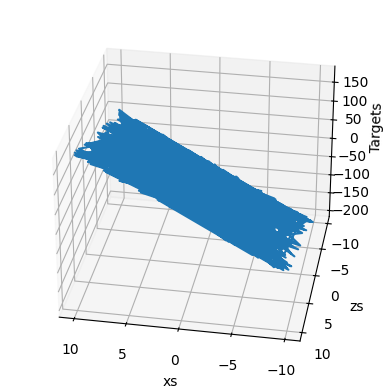

In [ ]:
targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
plot_limit = 1000

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs[:plot_limit], zs[:plot_limit], targets[:plot_limit])
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)

plt.show()

In [ ]:
init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print(weights, biases)

[[ 0.05824425]
 [-0.09533577]] [0.05257255]


In [ ]:
targets = targets.reshape(observations,1)
eta = 0.02
for i in range (100):
  outputs = np.dot(inputs, weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas ** 2)/2/observations
  print(loss)

  deltas_scaled = deltas/observations
  weights = weights - eta * np.dot(inputs.T, deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

3677.737170222173
484.38795067193576
114.78106090729956
69.86071013407735
62.43807734731131
59.432916342126994
57.0237213787273
54.765189097189506
52.60249584605885
50.5261765593568
48.53215223899718
46.61708782300679
44.777848090483886
43.011429856300346
41.31494976330359
39.68563872340903
38.12083729815755
36.617991346206885
35.174647852980044
33.78845092658173
32.45713795238409
31.178535899880593
29.950557775764814
28.771199217443716
27.638535221424526
26.55071700123489
25.505968969748558
24.50258584098987
23.53892984668739
22.613428063032718
21.72456984328186
20.870904352007706
20.051038196979505
19.26363315480375
18.507403986614104
17.78111634024526
17.083584735466268
16.413670628985038
15.770280556065313
15.152364345723152
14.558913406589301
13.988959080639738
13.441571062107474
12.915855878994334
12.410955434704855
11.926045607421349
11.460334904934223
11.013063172731808
10.583500353241172
10.17094529419433
9.774724604175208
9.394191553479033
9.028725018490297
8.677728467856078


In [ ]:
print(weights, biases)

[[12.99954487]
 [ 7.00419932]] [-10.40416981]


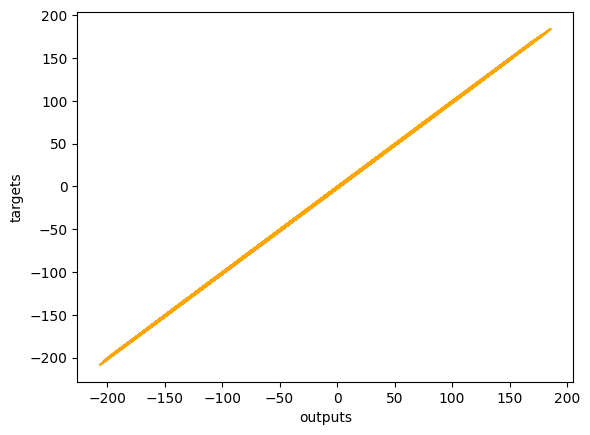

In [ ]:
plt.plot(outputs[:1000], targets[:1000], color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()